# Bioactivity Prediction Analysis

This notebook analyzes the results of bioactivity prediction experiments comparing
Morgan fingerprints (FP) and hyperdimensional computing (HDC) molecular representations.

**Visualization:**
- Bidirectional bar chart showing AUC (upward bars) and Enrichment Factor (downward bars)
- Side-by-side comparison of FP and HDC for each dataset
- Lighter color shades for EF bars to distinguish from AUC bars

**Primary Metrics:**
- AUC: Area Under ROC Curve (higher is better, range 0.5-1.0)
- EF: Enrichment Factor at configurable percentage (higher is better)

In [81]:
%matplotlib inline
import os
import json
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from rich.pretty import pprint
from pycomex.utils import is_experiment_archive
from pycomex.functional.experiment import Experiment

# Paths
PATH: str = os.getcwd()
RESULTS_PATH: str = os.path.join(PATH, 'results')

## Configuration

Configure which datasets to include and which enrichment factor percentage to display.

In [82]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# List of dataset names to include in the analysis
# These should match the DATASET_NAME parameter from experiment configurations
DATASETS: list[str] = [
    'riniker_1',
    'riniker_2',
    'muv',
    'dud_e',
]

# Human-readable labels for each dataset (for plot display)
DATASET_LABELS: dict[str, str] = {
    'riniker_1': 'Riniker 1',
    'riniker_2': 'Riniker 2',
    'muv': 'MUV',
    'dud_e': 'DUD-E'
}

# Enrichment Factor percentage to display (options: 1 or 5)
EF_PERCENTAGE: int = 1  # Will use 'ef1' or 'ef5' metric

# ============================================================================
# VISUAL CONFIGURATION
# ============================================================================

# Figure size (width, height) in inches
FIGSIZE: tuple[int, int] = (6, 4)

# Font size
FONT_SIZE: int = 11

# Whether to show value annotations on the bars
SHOW_VALUE_ANNOTATIONS: bool = False

# Colors for each encoding method
COLORS: dict[str, dict[str, str]] = {
    'fp': {
        'primary': '#7C92FF',     # Blue for FP - AUC bars
        'secondary': '#B8C4FF',   # Lighter blue for FP - EF bars
    },
    'hdc': {
        'primary': '#69F7AE',     # Green for HDC - AUC bars  
        'secondary': '#A8FACD',   # Lighter green for HDC - EF bars
    },
}

# Labels for encoding methods
ENCODING_LABELS: dict[str, str] = {
    'fp': 'Morgan FP',
    'hdc': 'HDC',
}

print(f'Configuration:')
print(f'  Datasets: {DATASETS}')
print(f'  EF Percentage: {EF_PERCENTAGE}%')
print(f'  Show Value Annotations: {SHOW_VALUE_ANNOTATIONS}')

Configuration:
  Datasets: ['riniker_1', 'riniker_2', 'muv', 'dud_e']
  EF Percentage: 1%
  Show Value Annotations: False


## Experiment Discovery

Find all archived bioactivity experiments in the results directory.

In [83]:
# Discover all experiment namespaces
experiment_namespace_paths: list[str] = [
    path
    for file_name in os.listdir(RESULTS_PATH)
    if os.path.isdir(path := os.path.join(RESULTS_PATH, file_name))
]

# Find all experiment archives
experiment_paths: list[str] = []
for namespace_path in experiment_namespace_paths:
    for dirpath, dirnames, filenames in os.walk(namespace_path):
        if is_experiment_archive(dirpath):
            experiment_paths.append(dirpath)
            dirnames.clear()  # Prevent recursion into subdirectories

print(f'Found {len(experiment_paths)} experiment archives in {len(experiment_namespace_paths)} namespaces')

Found 37457 experiment archives in 92 namespaces


## Filter and Load Bioactivity Experiments

Filter experiments to include only bioactivity prediction runs for the configured datasets,
then find the most recent experiment for each (dataset, encoding) combination.

In [84]:
def select_experiment(experiment_name: str,
                      experiment_metadata: dict,
                      experiment_parameters: dict) -> bool:
    """
    Filter experiments to include only bioactivity prediction experiments.
    """
    # Must be a bioactivity experiment (matches both 'predict_bioactivity' and 'bioactivity_*' naming)
    if 'bioactivity' not in experiment_name:
        return False
    
    # Check if dataset is in our list
    dataset = experiment_parameters.get('DATASET_NAME', '')
    if dataset in DATASETS:
        return True
    
    return False


def get_encoding_type(experiment_name: str) -> str:
    """
    Determine encoding type (fp or hdc) from experiment name.
    """
    if '__fp' in experiment_name or '_fp_' in experiment_name or 'fp_bioactivity' in experiment_name:
        return 'fp'
    elif '__hdc' in experiment_name or '_hdc_' in experiment_name or 'hdc_bioactivity' in experiment_name:
        return 'hdc'
    return 'unknown'


# Dictionary to store experiments grouped by (dataset, encoding)
# Each entry will be a list of (timestamp, experiment_path) tuples
grouped_experiments: dict[tuple[str, str], list[tuple[float, str]]] = defaultdict(list)

print('Scanning experiments...')
for experiment_path in experiment_paths:
    
    # Load metadata
    meta_path = os.path.join(experiment_path, Experiment.METADATA_FILE_NAME)
    if not os.path.exists(meta_path):
        continue
    
    with open(meta_path) as f:
        metadata = json.loads(f.read())
    
    if 'parameters' not in metadata:
        continue
    
    # Extract parameters
    parameters = {
        param: info['value']
        for param, info in metadata['parameters'].items()
        if 'value' in info
    }
    
    experiment_name = metadata.get('name', '')
    
    # Apply filter
    if not select_experiment(experiment_name, metadata, parameters):
        continue
    
    # Get dataset and encoding
    dataset = parameters.get('DATASET_NAME', '')
    encoding = get_encoding_type(experiment_name)
    
    if encoding == 'unknown':
        print(f'  Warning: Unknown encoding for {experiment_name}')
        continue
    
    # Get timestamp (end_time from metadata)
    timestamp = metadata.get('end_time', 0)
    
    # Store experiment
    key = (dataset, encoding)
    grouped_experiments[key].append((timestamp, experiment_path))
    
print(f'\nFound experiments for {len(grouped_experiments)} (dataset, encoding) combinations')
for key, exps in grouped_experiments.items():
    print(f'  {key}: {len(exps)} experiment(s)')

Scanning experiments...

Found experiments for 8 (dataset, encoding) combinations
  ('dud_e', 'fp'): 1 experiment(s)
  ('riniker_1', 'hdc'): 5 experiment(s)
  ('dud_e', 'hdc'): 1 experiment(s)
  ('riniker_2', 'fp'): 1 experiment(s)
  ('muv', 'fp'): 1 experiment(s)
  ('riniker_1', 'fp'): 4 experiment(s)
  ('muv', 'hdc'): 1 experiment(s)
  ('riniker_2', 'hdc'): 1 experiment(s)


In [85]:
# Select the most recent experiment for each (dataset, encoding) combination
most_recent_experiments: dict[tuple[str, str], str] = {}

print('Selecting most recent experiments...')
for key, experiments_list in grouped_experiments.items():
    # Sort by timestamp (descending) and take the most recent
    experiments_list = [e for e in experiments_list if e[0] is not None]
    sorted_exps = sorted(experiments_list, key=lambda x: x[0], reverse=True)
    most_recent_timestamp, most_recent_path = sorted_exps[0]
    most_recent_experiments[key] = most_recent_path
    
    # Format timestamp for display
    if most_recent_timestamp is not None and most_recent_timestamp > 0:
        dt = datetime.fromtimestamp(most_recent_timestamp)
        time_str = dt.strftime('%Y-%m-%d %H:%M')
    else:
        time_str = 'unknown time'
    
    print(f'  {key[0]:15s} | {key[1]:4s} | {time_str} | {os.path.basename(most_recent_path)}')

print(f'\nSelected {len(most_recent_experiments)} experiments')

Selecting most recent experiments...
  dud_e           | fp   | 2025-12-08 20:23 | debug
  riniker_1       | hdc  | 2025-12-08 16:27 | debug
  dud_e           | hdc  | 2025-12-08 21:45 | debug
  riniker_2       | fp   | 2025-12-08 19:51 | debug
  muv             | fp   | 2025-12-08 17:25 | debug
  riniker_1       | fp   | 2025-12-05 20:32 | ex_09_a__05_12_2025__20_08__Y5rh
  muv             | hdc  | 2025-12-08 14:06 | debug
  riniker_2       | hdc  | 2025-12-08 18:11 | debug

Selected 8 experiments


## Extract Metrics

Load AUC and Enrichment Factor metrics from the aggregated results CSV files.

In [86]:
# Dictionary to store extracted metrics
# Structure: metrics_data[(dataset, encoding)] = {'auc': {...}, 'ef': {...}}
metrics_data: dict[tuple[str, str], dict] = {}

ef_metric_name = f'ef{EF_PERCENTAGE}'  # e.g., 'ef1' or 'ef5'

print(f'Extracting metrics (AUC and {ef_metric_name.upper()})...')
print('-' * 70)

for key, experiment_path in most_recent_experiments.items():
    dataset, encoding = key
    
    # Load aggregated results
    csv_path = os.path.join(experiment_path, 'aggregated_results.csv')
    
    if not os.path.exists(csv_path):
        print(f'  Warning: No aggregated_results.csv found for {key}')
        continue
    
    df = pd.read_csv(csv_path)
    
    # Extract AUC metrics
    auc_row = df[df['metric'] == 'auc']
    if len(auc_row) == 0:
        print(f'  Warning: No AUC metric found for {key}')
        continue
    
    auc_mean = auc_row['mean'].values[0]
    auc_std = auc_row['std'].values[0]
    
    # Extract EF metrics
    ef_row = df[df['metric'] == ef_metric_name]
    if len(ef_row) == 0:
        print(f'  Warning: No {ef_metric_name} metric found for {key}')
        continue
    
    ef_mean = ef_row['mean'].values[0]
    ef_std = ef_row['std'].values[0]
    
    # Store metrics
    metrics_data[key] = {
        'auc': {'mean': auc_mean, 'std': auc_std},
        'ef': {'mean': ef_mean, 'std': ef_std},
    }
    
    print(f'  {dataset:15s} | {encoding:4s} | AUC: {auc_mean:.3f} +/- {auc_std:.3f} | {ef_metric_name.upper()}: {ef_mean:.2f} +/- {ef_std:.2f}')

print('-' * 70)
print(f'Extracted metrics for {len(metrics_data)} experiments')

Extracting metrics (AUC and EF1)...
----------------------------------------------------------------------
  dud_e           | fp   | AUC: 0.799 +/- 0.087 | EF1: 30.88 +/- 11.79
  riniker_1       | hdc  | AUC: 0.541 +/- 0.082 | EF1: 9.10 +/- 6.13
  dud_e           | hdc  | AUC: 0.571 +/- 0.041 | EF1: 7.35 +/- 3.67
  riniker_2       | fp   | AUC: 0.740 +/- 0.113 | EF1: 23.64 +/- 15.51
  muv             | fp   | AUC: 0.545 +/- 0.072 | EF1: 4.72 +/- 3.20
  riniker_1       | fp   | AUC: 0.583 +/- 0.102 | EF1: 5.30 +/- 3.94
  muv             | hdc  | AUC: 0.544 +/- 0.043 | EF1: 2.22 +/- 1.07
  riniker_2       | hdc  | AUC: 0.631 +/- 0.093 | EF1: 13.64 +/- 9.85
----------------------------------------------------------------------
Extracted metrics for 8 experiments


## Visualization: Bidirectional Bar Chart

Create a bar chart with:
- **Upward bars**: AUC values (primary colors)
- **Downward bars**: Enrichment Factor values (lighter colors)
- **Side-by-side**: FP and HDC for each dataset


Plot Values (AUC and EF1%):
----------------------------------------------------------------------
Dataset         | Encoding | AUC                  | EF                  
----------------------------------------------------------------------
Riniker 1       | Morgan FP | 0.583 +/- 0.102    | 5.30 +/- 3.94
Riniker 2       | Morgan FP | 0.740 +/- 0.113    | 23.64 +/- 15.51
MUV             | Morgan FP | 0.545 +/- 0.072    | 4.72 +/- 3.20
DUD-E           | Morgan FP | 0.799 +/- 0.087    | 30.88 +/- 11.79
Riniker 1       | HDC      | 0.541 +/- 0.082    | 9.10 +/- 6.13
Riniker 2       | HDC      | 0.631 +/- 0.093    | 13.64 +/- 9.85
MUV             | HDC      | 0.544 +/- 0.043    | 2.22 +/- 1.07
DUD-E           | HDC      | 0.571 +/- 0.041    | 7.35 +/- 3.67
----------------------------------------------------------------------

Saved figure to /media/ssd2/Programming/graph_hdc/graph_hdc/experiments/fingerprints/figures/bioactivity_comparison.svg
Saved figure to /media/ssd2/Programming/gra

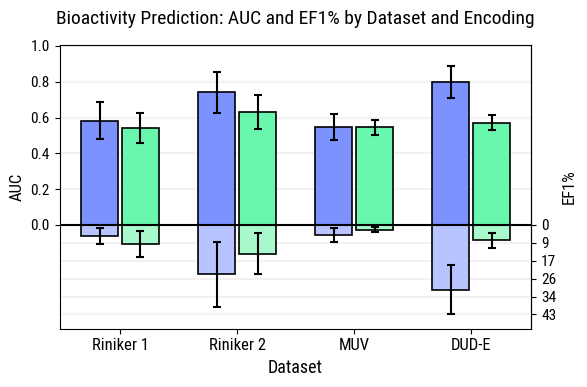

In [92]:
%matplotlib inline

# ============================================================================
# VISUALIZATION
# ============================================================================

plt.style.use('default')
plt.rcParams['font.family'] = 'Roboto Condensed'
plt.rcParams['font.size'] = FONT_SIZE

fig, ax = plt.subplots(figsize=FIGSIZE)

# Setup
n_datasets = len(DATASETS)
encodings = ['fp', 'hdc']
bar_width = 0.35
x_positions = np.arange(n_datasets)

# For normalization of EF values (to make downward bars visually balanced)
# We'll scale EF to fit nicely below the axis
all_ef_values = [m['ef']['mean'] + m['ef']['std'] for m in metrics_data.values() if 'ef' in m]
max_ef = max(all_ef_values) if all_ef_values else 10
ef_scale_factor = 0.5 / max_ef  # Scale EF to max ~0.5 on the plot

# Track which encodings have data for legend
legend_handles = []
legend_labels_added = set()

# Print header for values
print(f'\nPlot Values (AUC and EF{EF_PERCENTAGE}%):')
print('-' * 70)
print(f'{"Dataset":<15} | {"Encoding":<8} | {"AUC":<20} | {"EF":<20}')
print('-' * 70)

for enc_idx, encoding in enumerate(encodings):
    
    # Position offset for side-by-side bars
    offset = (enc_idx - 0.5) * bar_width
    
    for ds_idx, dataset in enumerate(DATASETS):
        key = (dataset, encoding)
        x = x_positions[ds_idx] + offset
        
        if key not in metrics_data:
            # No data for this combination - skip but still show in plot
            continue
        
        metrics = metrics_data[key]
        
        # --- AUC Bar (upward) ---
        auc_mean = metrics['auc']['mean']
        auc_std = metrics['auc']['std']
        
        auc_bar = ax.bar(
            x, auc_mean,
            width=bar_width * 0.9,
            color=COLORS[encoding]['primary'],
            edgecolor='black',
            linewidth=1.2,
            yerr=auc_std,
            capsize=3,
            error_kw={'linewidth': 1.5, 'capthick': 1.5},
            label=f'{ENCODING_LABELS[encoding]} AUC' if encoding not in legend_labels_added else None,
        )
        
        # --- EF Bar (downward) ---
        ef_mean = metrics['ef']['mean']
        ef_std = metrics['ef']['std']
        
        # Scale EF for display (negative to go downward)
        ef_scaled = -ef_mean * ef_scale_factor
        ef_std_scaled = ef_std * ef_scale_factor
        
        ef_bar = ax.bar(
            x, ef_scaled,
            width=bar_width * 0.9,
            color=COLORS[encoding]['secondary'],
            edgecolor='black',
            linewidth=1.2,
            yerr=ef_std_scaled,
            capsize=3,
            error_kw={'linewidth': 1.5, 'capthick': 1.5},
        )
        
        # Print values
        dataset_label = DATASET_LABELS.get(dataset, dataset)
        print(f'{dataset_label:<15} | {ENCODING_LABELS[encoding]:<8} | {auc_mean:.3f} +/- {auc_std:.3f}    | {ef_mean:.2f} +/- {ef_std:.2f}')
        
        # Add value annotations (if enabled)
        if SHOW_VALUE_ANNOTATIONS:
            # AUC value above bar
            ax.annotate(
                f'{auc_mean:.2f}',
                xy=(x, auc_mean + auc_std + 0.02),
                ha='center', va='bottom',
                fontsize=FONT_SIZE - 2,
                fontweight='bold',
            )
            
            # EF value below bar
            ax.annotate(
                f'{ef_mean:.1f}',
                xy=(x, ef_scaled - ef_std_scaled - 0.02),
                ha='center', va='top',
                fontsize=FONT_SIZE - 2,
                fontweight='bold',
            )
        
        legend_labels_added.add(encoding)

print('-' * 70)

# ============================================================================
# AXIS CONFIGURATION
# ============================================================================

# X-axis: dataset labels
ax.set_xticks(x_positions)
ax.set_xticklabels([DATASET_LABELS.get(d, d) for d in DATASETS], fontsize=FONT_SIZE + 1)
ax.set_xlabel('Dataset', fontsize=FONT_SIZE + 2)

# Y-axis: AUC label on left only
ax.set_ylabel('AUC', fontsize=FONT_SIZE + 1)

# Add horizontal line at y=0
ax.axhline(y=0, color='black', linewidth=1.5, linestyle='-')

# Add reference line for random AUC (0.5)
# ax.axhline(y=0.5, color='gray', linewidth=1, linestyle='--', alpha=0.7)
# ax.annotate('Random AUC', xy=(n_datasets - 0.5, 0.52), ha='right', va='bottom',
#             fontsize=FONT_SIZE - 2, color='gray', style='italic')

# Title
ax.set_title(
    f'Bioactivity Prediction: AUC and EF{EF_PERCENTAGE}% by Dataset and Encoding',
    fontsize=FONT_SIZE + 3,
    pad=15
)

# Custom legend
legend_elements = [
    Patch(facecolor=COLORS['fp']['primary'], edgecolor='black', label=f'{ENCODING_LABELS["fp"]} (AUC)'),
    Patch(facecolor=COLORS['fp']['secondary'], edgecolor='black', label=f'{ENCODING_LABELS["fp"]} (EF{EF_PERCENTAGE}%)'),
    Patch(facecolor=COLORS['hdc']['primary'], edgecolor='black', label=f'{ENCODING_LABELS["hdc"]} (AUC)'),
    Patch(facecolor=COLORS['hdc']['secondary'], edgecolor='black', label=f'{ENCODING_LABELS["hdc"]} (EF{EF_PERCENTAGE}%)'),
]
#ax.legend(handles=legend_elements, loc='upper right', fontsize=FONT_SIZE - 1, ncol=2)

# Calculate y-limits with extra padding for error bars and annotations
y_max_data = max([m['auc']['mean'] + m['auc']['std'] for m in metrics_data.values()]) if metrics_data else 1.0
y_max = y_max_data + 0.12  # Extra space for annotations

# Calculate minimum y based on scaled EF values with error bars
y_min_data = min([-m['ef']['mean'] * ef_scale_factor - m['ef']['std'] * ef_scale_factor
                  for m in metrics_data.values()]) if metrics_data else -0.6
y_min = y_min_data - 0.08  # Extra space for annotations

ax.set_ylim(y_min, y_max)

# Custom y-axis ticks for left side (AUC): only show non-negative values
auc_ticks = [t for t in np.arange(0, y_max + 0.1, 0.2) if t >= 0]
ax.set_yticks(auc_ticks)
ax.set_yticklabels([f'{t:.1f}' for t in auc_ticks])

# Add grid lines manually for both AUC and EF regions
for tick in auc_ticks:
    ax.axhline(y=tick, color='gray', alpha=0.1, linestyle='-', zorder=0)

# Add secondary y-axis for EF scale (right side, showing positive EF values)
ax2 = ax.secondary_yaxis('right')
ax2.set_ylabel(f'EF{EF_PERCENTAGE}%', fontsize=FONT_SIZE + 1)

# Create EF tick positions and labels (negative positions, positive labels)
ef_tick_step = 0.1
ef_ticks = [t for t in np.arange(0, y_min - 0.01, -ef_tick_step)]
ef_labels = [f'{abs(t)/ef_scale_factor:.0f}' for t in ef_ticks]
ax2.set_yticks(ef_ticks)
ax2.set_yticklabels(ef_labels)

# Add grid lines for EF region (negative y values)
for tick in ef_ticks:
    if tick < 0:  # Only for negative ticks (EF region)
        ax.axhline(y=tick, color='gray', alpha=0.1, linestyle='-', zorder=0)

plt.tight_layout()

# Save figure
fig_dir = os.path.join(PATH, 'figures')
os.makedirs(fig_dir, exist_ok=True)
fig_path = os.path.join(fig_dir, 'bioactivity_comparison.svg')
plt.savefig(fig_path, bbox_inches='tight', dpi=300)
print(f'\nSaved figure to {fig_path}')

fig_path_pdf = os.path.join(fig_dir, 'bioactivity_comparison.pdf')
plt.savefig(fig_path_pdf, bbox_inches='tight', dpi=300)
print(f'Saved figure to {fig_path_pdf}')

plt.show()

## Summary Table

Generate a summary table with all metrics for easy reference.

In [ ]:
# Build summary table
table_rows = []

for dataset in DATASETS:
    row = {'Dataset': DATASET_LABELS.get(dataset, dataset)}
    
    for encoding in ['fp', 'hdc']:
        key = (dataset, encoding)
        
        if key in metrics_data:78
        
            auc = metrics_data[key]['auc']
            ef = metrics_data[key]['ef']
            row[f'{ENCODING_LABELS[encoding]} AUC'] = f"{auc['mean']:.3f} +/- {auc['std']:.3f}"
            row[f'{ENCODING_LABELS[encoding]} EF{EF_PERCENTAGE}%'] = f"{ef['mean']:.2f} +/- {ef['std']:.2f}"
        else:
            row[f'{ENCODING_LABELS[encoding]} AUC'] = 'N/A'
            row[f'{ENCODING_LABELS[encoding]} EF{EF_PERCENTAGE}%'] = 'N/A'
    
    table_rows.append(row)

df_summary = pd.DataFrame(table_rows)
print('Summary Table:')
print('=' * 100)
display(df_summary)

Summary Table:


,Dataset,Morgan FP AUC,Morgan FP EF1%,HDC AUC,HDC EF1%
0,Riniker 1,0.583 +/- 0.102,5.30 +/- 3.94,0.541 +/- 0.082,9.10 +/- 6.13
1,Riniker 2,0.740 +/- 0.113,23.64 +/- 15.51,0.631 +/- 0.093,13.64 +/- 9.85
2,MUV,0.545 +/- 0.072,4.72 +/- 3.20,0.544 +/- 0.043,2.22 +/- 1.07
3,DUD-E,0.799 +/- 0.087,30.88 +/- 11.79,0.571 +/- 0.041,7.35 +/- 3.67


In [89]:
# Generate LaTeX table
latex_table = r"""
\begin{table}[htbp]
\centering
\caption{Bioactivity Prediction Performance: AUC and EF""" + str(EF_PERCENTAGE) + r"""\% across datasets}
\label{tab:bioactivity}
\begin{tabular}{lcccc}
\toprule
\textbf{Dataset} & \textbf{FP AUC} & \textbf{FP EF""" + str(EF_PERCENTAGE) + r"""%} & \textbf{HDC AUC} & \textbf{HDC EF""" + str(EF_PERCENTAGE) + r"""%} \\
\midrule
"""

for dataset in DATASETS:
    label = DATASET_LABELS.get(dataset, dataset)
    
    fp_key = (dataset, 'fp')
    hdc_key = (dataset, 'hdc')
    
    if fp_key in metrics_data:
        fp_auc = f"{metrics_data[fp_key]['auc']['mean']:.3f} $\\pm$ {metrics_data[fp_key]['auc']['std']:.3f}"
        fp_ef = f"{metrics_data[fp_key]['ef']['mean']:.2f} $\\pm$ {metrics_data[fp_key]['ef']['std']:.2f}"
    else:
        fp_auc = 'N/A'
        fp_ef = 'N/A'
    
    if hdc_key in metrics_data:
        hdc_auc = f"{metrics_data[hdc_key]['auc']['mean']:.3f} $\\pm$ {metrics_data[hdc_key]['auc']['std']:.3f}"
        hdc_ef = f"{metrics_data[hdc_key]['ef']['mean']:.2f} $\\pm$ {metrics_data[hdc_key]['ef']['std']:.2f}"
    else:
        hdc_auc = 'N/A'
        hdc_ef = 'N/A'
    
    latex_table += f"{label} & {fp_auc} & {fp_ef} & {hdc_auc} & {hdc_ef} \\\\\n"

latex_table += r"""\bottomrule
\end{tabular}
\end{table}
"""

print('LaTeX Table:')
print('=' * 80)
print(latex_table)

# Save LaTeX to file
latex_path = os.path.join(fig_dir, 'bioactivity_table.tex')
with open(latex_path, 'w') as f:
    f.write(latex_table)
print(f'\nSaved LaTeX table to {latex_path}')

LaTeX Table:

\begin{table}[htbp]
\centering
\caption{Bioactivity Prediction Performance: AUC and EF1\% across datasets}
\label{tab:bioactivity}
\begin{tabular}{lcccc}
\toprule
\textbf{Dataset} & \textbf{FP AUC} & \textbf{FP EF1%} & \textbf{HDC AUC} & \textbf{HDC EF1%} \\
\midrule
Riniker 1 & 0.583 $\pm$ 0.102 & 5.30 $\pm$ 3.94 & 0.541 $\pm$ 0.082 & 9.10 $\pm$ 6.13 \\
Riniker 2 & 0.740 $\pm$ 0.113 & 23.64 $\pm$ 15.51 & 0.631 $\pm$ 0.093 & 13.64 $\pm$ 9.85 \\
MUV & 0.545 $\pm$ 0.072 & 4.72 $\pm$ 3.20 & 0.544 $\pm$ 0.043 & 2.22 $\pm$ 1.07 \\
DUD-E & 0.799 $\pm$ 0.087 & 30.88 $\pm$ 11.79 & 0.571 $\pm$ 0.041 & 7.35 $\pm$ 3.67 \\
\bottomrule
\end{tabular}
\end{table}


Saved LaTeX table to /media/ssd2/Programming/graph_hdc/graph_hdc/experiments/fingerprints/figures/bioactivity_table.tex


## Analysis Summary

Key findings from the bioactivity prediction experiments.

In [90]:
print('=' * 80)
print('BIOACTIVITY PREDICTION ANALYSIS SUMMARY')
print('=' * 80)

print(f'\nDatasets analyzed: {len(DATASETS)}')
print(f'Experiments loaded: {len(metrics_data)}')
print(f'EF metric: EF{EF_PERCENTAGE}%')

# Find best performing method per dataset
print('\n' + '-' * 40)
print('Best Performing Method per Dataset (AUC):')
print('-' * 40)

for dataset in DATASETS:
    fp_key = (dataset, 'fp')
    hdc_key = (dataset, 'hdc')
    
    fp_auc = metrics_data.get(fp_key, {}).get('auc', {}).get('mean', 0)
    hdc_auc = metrics_data.get(hdc_key, {}).get('auc', {}).get('mean', 0)
    
    if fp_auc > 0 or hdc_auc > 0:
        best = 'FP' if fp_auc > hdc_auc else 'HDC'
        diff = abs(fp_auc - hdc_auc)
        print(f'  {DATASET_LABELS.get(dataset, dataset):15s}: {best} (AUC diff: {diff:.3f})')
    else:
        print(f'  {DATASET_LABELS.get(dataset, dataset):15s}: No data')

# Overall comparison
print('\n' + '-' * 40)
print('Overall Mean Performance:')
print('-' * 40)

for encoding in ['fp', 'hdc']:
    auc_values = [m['auc']['mean'] for k, m in metrics_data.items() if k[1] == encoding]
    ef_values = [m['ef']['mean'] for k, m in metrics_data.items() if k[1] == encoding]
    
    if auc_values:
        print(f'  {ENCODING_LABELS[encoding]:10s}: AUC = {np.mean(auc_values):.3f}, EF{EF_PERCENTAGE}% = {np.mean(ef_values):.2f}')
    else:
        print(f'  {ENCODING_LABELS[encoding]:10s}: No data')

print('\n' + '=' * 80)

BIOACTIVITY PREDICTION ANALYSIS SUMMARY

Datasets analyzed: 4
Experiments loaded: 8
EF metric: EF1%

----------------------------------------
Best Performing Method per Dataset (AUC):
----------------------------------------
  Riniker 1      : FP (AUC diff: 0.042)
  Riniker 2      : FP (AUC diff: 0.109)
  MUV            : FP (AUC diff: 0.000)
  DUD-E          : FP (AUC diff: 0.227)

----------------------------------------
Overall Mean Performance:
----------------------------------------
  Morgan FP : AUC = 0.667, EF1% = 16.14
  HDC       : AUC = 0.572, EF1% = 8.08

